In [1]:
from warnings import filterwarnings
import random

import torch.cuda as cuda

import sys
sys.path.append('../')

from scformer.model import *
from scformer.utils import *

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
adata = sc.read_h5ad('../data/pbmc_benchmark_data/pbmc.h5ad')
mapping_dict = {
    'Naive CD20+ B IGKC+': 'Naïve CD20+ B',
    'Naive CD20+ B IGKC-': 'Naïve CD20+ B',
    'CD14+ Mono': 'CD14+ Mono',
    'HSC': 'HSC',
    'Reticulocyte': 'Erythroblast',
    'Normoblast': 'Normoblast',
    'NK CD158e1+': 'NK',
    'CD4+ T naive': 'CD4+ T naïve',
    'Erythroblast': 'Erythroblast',
    'NK': 'NK',
    'B1 B IGKC+': 'B1 B',
    'B1 B IGKC-': 'B1 B',
    'CD4+ T activated': 'CD4+ T activated',
    'CD4+ T activated integrinB7+': 'CD4+ T activated',
    'pDC': 'pDC',
    'Proerythroblast': 'Proerythroblast',
    'Transitional B': 'Transitional B',
    'MAIT': 'CD8+ T',
    'CD8+ T naive': 'CD8+ T naïve',
    'CD8+ T naive CD127+ CD26- CD101-': 'CD8+ T naïve',
    'T reg': 'CD4+ T activated',
    'CD8+ T CD49f+': 'CD8+ T',
    'CD8+ T TIGIT+ CD45RO+': 'CD8+ T',
    'gdT TCRVD2+': 'CD8+ T',  # gdT 类型被归入 CD8+ T
    'CD8+ T CD57+ CD45RA+': 'CD8+ T',
    'Lymph prog': 'Lymph prog',
    'Plasmablast IGKC+': 'Plasma cell',
    'Plasmablast IGKC-': 'Plasma cell',
    'CD8+ T CD69+ CD45RO+': 'CD8+ T',
    'CD8+ T TIGIT+ CD45RA+': 'CD8+ T',
    'CD8+ T CD69+ CD45RA+': 'CD8+ T',
    'ILC1': 'ILC',
    'cDC2': 'cDC2',
    'CD16+ Mono': 'CD16+ Mono',
    'G/M prog': 'G/Mprog',
    'MK/E prog': 'MK/E prog',
    'Plasma cell IGKC+': 'Plasma cell',
    'Plasma cell IGKC-': 'Plasma cell',
    'CD4+ T CD314+ CD45RA+': 'CD4+ T naïve',
    'ILC': 'ILC',
    'gdT CD158b+': 'CD8+ T',  # gdT 类型被归入 CD8+ T
    'CD8+ T CD57+ CD45RO+': 'CD8+ T',
    'dnT': None,  # 不需要的类型设为 None
    'cDC1': 'cDC2',  # 映射到 cDC2
    'T prog cycling': 'Lymph prog',  # 映射到 Lymph prog
}
adata.obs['Annotation'] = adata.obs['cell_type'].map(mapping_dict)
adata = adata[~adata.obs['Annotation'].isna()]

output_dir = '../output/pbmc_benchmark_data_2/'
os.makedirs(os.path.dirname(output_dir), exist_ok=True)

adata.write(output_dir + '/pbmc_benchmark.h5ad')

adata_train = adata[adata.obs['batch'].isin(['s1d1', 's2d1', 's3d1'])]
adata_test = adata[adata.obs['batch'].isin(['s4d1'])]

adata_train.write(output_dir + '/adata_train.h5ad')
adata_test.write(output_dir + '/adata_test.h5ad')

In [3]:
batch_labels_list = adata_train.obs['batch']
enable_batch_correction = True
# batch_labels_list = None
# enable_batch_correction = False

In [4]:
annotation_to_num = {ann: idx for idx, ann in enumerate(adata_train.obs['Annotation'].unique())}
# Create a new column with numerical labels
adata_train.obs['Annotation_num'] = adata_train.obs['Annotation'].map(annotation_to_num)

In [5]:
RNA_matrix = adata_train.X.transpose()

initial_pre = adata_train.obs['Annotation_num']
cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]

cell_size = 30

In [6]:
indices, Node_Ids, dic = batch_select_whole(RNA_matrix, cell_size=cell_size, save_path=output_dir + 'graph_preprocess')
n_batch = len(indices)
device = torch.device("cuda" if cuda.is_available() else "cpu")

node_model = NDR_2(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                   enable_batch_correction=enable_batch_correction,
                   batch_source=batch_labels_list,
                   n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                   num_relations=2, epochs=100)
# gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch)

正在从磁盘加载处理后的数据...


In [7]:
node_model.load_model(output_dir + 'node_model.pth')
gnn = node_model.gnn

Model loaded successfully from ../output/pbmc_benchmark_data_2/node_model.pth.


In [10]:
import scipy.sparse as sp

RNA_matrix = adata_test.X.transpose()
# 获取原始矩阵的大小
genes, current_cells = RNA_matrix.shape

# 目标列数（细胞数）
target_cells = 25213  # 替换为训练数据的细胞数

# 计算需要扩展的次数
repeat_times = (target_cells + current_cells - 1) // current_cells  # 向上取整

# 扩展列数
if sp.issparse(RNA_matrix):
    # 如果 RNA_matrix 是稀疏矩阵
    expanded_matrix = sp.hstack([RNA_matrix] * repeat_times)[:, :target_cells]
elif isinstance(RNA_matrix, np.ndarray):
    # 如果 RNA_matrix 是 numpy 数组
    expanded_matrix = np.tile(RNA_matrix, (1, repeat_times))[:, :target_cells]
else:
    raise TypeError("RNA_matrix should be a scipy sparse matrix or numpy.ndarray")

# 输出扩展后的矩阵大小
print(f"Expanded RNA_matrix shape: {expanded_matrix.shape}")

Expanded RNA_matrix shape: (14087, 25213)


In [12]:
indices, Node_Ids, dic = batch_select_whole(expanded_matrix, cell_size=cell_size, save_path=output_dir + 'graph_preprocess_s1d4')

正在将数据划分为批次并进行并行处理。请稍候...


处理批次: 100%|██████████| 841/841 [10:25<00:00,  1.34it/s]


In [13]:
ScFormer_result = pred(
    expanded_matrix, gnn=gnn, indices=indices, device=device
)

Prediction Batches: 100%|██████████| 841/841 [07:26<00:00,  1.88it/s]


In [14]:
# Save numpy arrays to files
# output_file = "data/mouse_retina/output"
np.save(output_dir + "/Node_Ids_test.npy", Node_Ids)
np.save(output_dir + "/pred_test.npy", ScFormer_result["pred_label"])
np.save(output_dir + "/cell_embedding_test.npy", ScFormer_result["cell_embedding"])

In [17]:
node_ids = np.load(output_dir + "/Node_Ids_test.npy")
cell_emb = np.load(output_dir + "/cell_embedding_test.npy")
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
cell_emb_sorted = cell_emb_sorted.iloc[:RNA_matrix.shape[1],]

In [18]:
adata_test.obsm["cell_emb"] = cell_emb_sorted.values

In [22]:
pred = np.load(output_dir + '/pred_test.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
pred_sorted = pred_sorted.iloc[:RNA_matrix.shape[1],]

In [23]:
adata_test.obs['pre'] = pred_sorted.values
adata_test.obs['pre'] = adata_test.obs['pre'].astype('category')

In [24]:
adata_test.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata_test, use_rep="cell_emb")
sc.tl.umap(adata_test, random_state=seed)

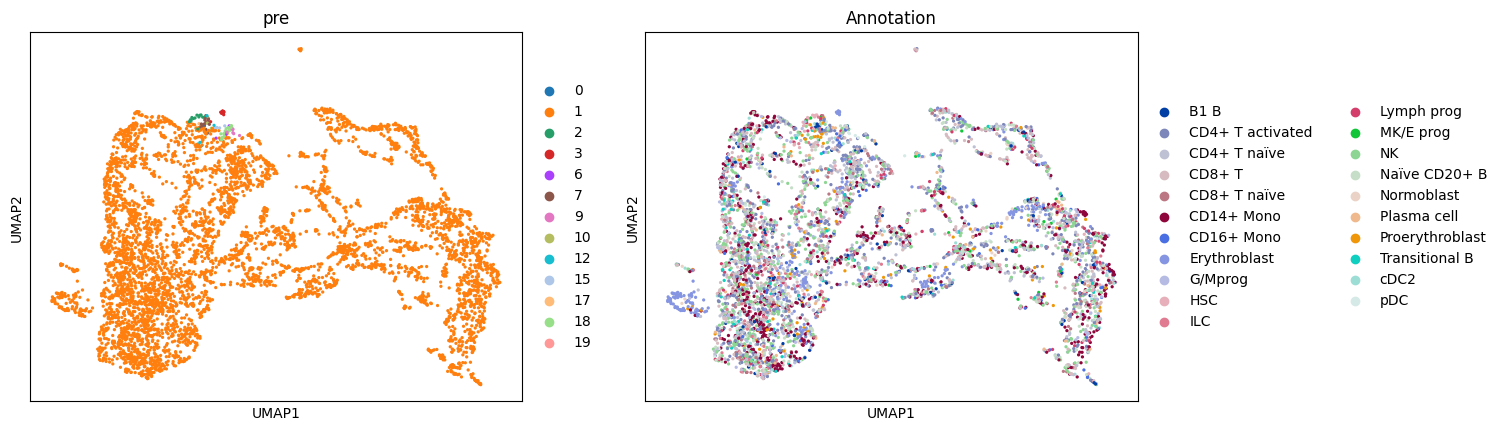

In [25]:
sc.pl.umap(adata_test, color=['pre', 'Annotation'], show=True)